# Task 1: Data Cleaning & Preprocessing (Titanic)

## Objective
Learn how to clean and prepare raw data for machine learning using Python, Pandas, NumPy, and Matplotlib/Seaborn.

## Steps Performed

1. Loaded the Titanic dataset and explored basic info (shape, columns, data types, missing values).
2. Handled missing values:
   - `Age`: median imputation  
   - `Embarked`: most frequent value  
   - `Cabin`: created binary feature `HasCabin`, then dropped `Cabin`
3. Selected features and target (`Survived`).
4. Encoded categorical features (`Sex`, `Embarked`) using one‑hot encoding.
5. Standardized numerical features using `StandardScaler`.
6. Detected outliers using boxplots on `Age`, `Fare`, and `SibSp`.
7. Removed outliers using the IQR rule.
8. Built a preprocessing pipeline ready for machine learning models.

## How to Run

1. Download the Titanic dataset (`train.csv` or `titanic.csv`) from Kaggle or your course link.
2. Upload the CSV to the same folder as this notebook (in Colab: Files panel → Upload).
3. Update the file name in the code if needed (e.g. `pd.read_csv("titanic.csv")`).
4. Run all cells in order (Runtime → Run all).

## Interview Questions (Short Answers)

1. **What are the different types of missing data?**  
   - MCAR (Missing Completely At Random)  
   - MAR (Missing At Random)  
   - MNAR (Missing Not At Random)

2. **How do you handle categorical variables?**  
   - Use encoding: one‑hot encoding for nominal variables, label/ordinal encoding for ordered categories.

3. **What is the difference between normalization and standardization?**  
   - Normalization (min‑max scaling): rescales features to a fixed range, usually [0, 1].  
   - Standardization (z‑score): rescales features to mean 0 and variance 1.

4. **How do you detect outliers?**  
   - Visually: boxplots, scatter plots.  
   - Statistically: IQR rule, z‑scores (e.g. |z| > 3).

5. **Why is preprocessing important in ML?**  
   - Models expect clean, numeric, scaled inputs. Preprocessing improves convergence, stability, and often accuracy.

6. **What is one‑hot encoding vs label encoding?**  
   - One‑hot: creates binary columns for each category (no implied order).  
   - Label: maps categories to integers (can imply order).

7. **How do you handle data imbalance?**  
   - Resampling: oversampling (e.g. SMOTE), undersampling.  
   - Algorithmic: class weights, threshold tuning, using metrics like F1, ROC‑AUC.

8. **Can preprocessing affect model accuracy?**  
   - Yes. Good preprocessing usually improves accuracy; bad preprocessing can hurt it.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/sample_data/mnist_train_small.csv")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Example: if your Titanic CSV is at:
# /content/drive/MyDrive/titanic/train.csv
df = pd.read_csv("/content/drive/MyDrive/titanic/train.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/titanic/train.csv'

In [ ]:
import os

# List top-level folders/files in your Drive
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'Classroom',
 'Roll No.- E 48_20240427_115809_0000.png',
 'IMG-20240904-WA0007.jpg',
 'Roll No.- E 48_20240427_115809_0000.gdoc',
 'Product Process & Management.gdoc',
 'PIE CAE III QB (3).gdoc',
 'PIE CAE III QB (2).gdoc',
 'PIE CAE III QB (1).gdoc',
 'PIE CAE III QB.gdoc',
 '1st_unit EEIM.docx.gdoc',
 'Resume (1).gdoc',
 'Resume.gdoc',
 'Purab B48 QCAM.pdf',
 'DSA notes .pdf',
 'Google Earth',
 'AQC.pdf',
 'AQC_Unit_I_Study_Notes.pdf',
 'Examination Guidelines - HWI Qualifiers.pdf',
 'Purab_Roy_Resume.gdoc',
 'AQC_Unit_I_Study_Notes (1).pdf',
 'AQC (1).pdf',
 'Unit___IV___Quantum_AI_and_Machine_Learning.gdoc',
 'Saved from Chrome',
 'Unit___I___Basic_Oracle_Based_Quantum_Algorithms.gdoc',
 'aqc ese paper.jpg',
 'Unit___IV___Quantum_AI_and_Machine_Learning (2).pdf',
 'Unit___III___Quantum_Search_and_Optimization_Algorithms (2).pdf',
 'Quantum_Oracle (1).pdf',
 'Unit___V___Quantum_Cryptography_and_Communication.pdf',
 'Project_Module_to_Research_Paper_Mapping.gdoc'

In [ ]:
os.listdir("/content/drive/MyDrive/datasets")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datasets'

In [ ]:
import os

# List top-level folders/files in your Drive
os.listdir("/content/drive/MyDrive")

['Colab Notebooks',
 'Classroom',
 'Roll No.- E 48_20240427_115809_0000.png',
 'IMG-20240904-WA0007.jpg',
 'Roll No.- E 48_20240427_115809_0000.gdoc',
 'Product Process & Management.gdoc',
 'PIE CAE III QB (3).gdoc',
 'PIE CAE III QB (2).gdoc',
 'PIE CAE III QB (1).gdoc',
 'PIE CAE III QB.gdoc',
 '1st_unit EEIM.docx.gdoc',
 'Resume (1).gdoc',
 'Resume.gdoc',
 'Purab B48 QCAM.pdf',
 'DSA notes .pdf',
 'Google Earth',
 'AQC.pdf',
 'AQC_Unit_I_Study_Notes.pdf',
 'Examination Guidelines - HWI Qualifiers.pdf',
 'Purab_Roy_Resume.gdoc',
 'AQC_Unit_I_Study_Notes (1).pdf',
 'AQC (1).pdf',
 'Unit___IV___Quantum_AI_and_Machine_Learning.gdoc',
 'Saved from Chrome',
 'Unit___I___Basic_Oracle_Based_Quantum_Algorithms.gdoc',
 'aqc ese paper.jpg',
 'Unit___IV___Quantum_AI_and_Machine_Learning (2).pdf',
 'Unit___III___Quantum_Search_and_Optimization_Algorithms (2).pdf',
 'Quantum_Oracle (1).pdf',
 'Unit___V___Quantum_Cryptography_and_Communication.pdf',
 'Project_Module_to_Research_Paper_Mapping.gdoc'

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
# Load data
# df = pd.read_csv("train.csv")  # or your Drive path - Removed as df is already loaded

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())

df.head()

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Age: median imputation
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: create binary feature and drop original
df["HasCabin"] = df["Cabin"].notna().astype(int)
df = df.drop(columns=["Cabin"])

# Check missing values again
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Target
y = df["Survived"]

# Columns to drop
drop_cols = ["PassengerId", "Name", "Ticket", "Survived"]

# Features
X = df.drop(columns=drop_cols)

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,0
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [ ]:
numeric_features = ["Age", "SibSp", "Fare", "Pclass", "HasCabin"]
categorical_features = ["Sex", "Embarked"]

In [ ]:
# Numerical pipeline: impute + standardize
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Full preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor)
])

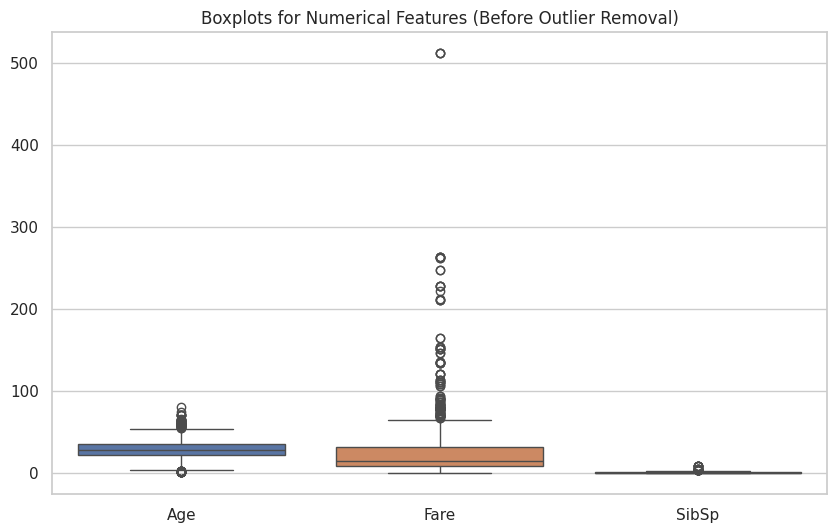

In [ ]:
num_cols_for_outliers = ["Age", "Fare", "SibSp"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols_for_outliers])
plt.title("Boxplots for Numerical Features (Before Outlier Removal)")
plt.show()

In [ ]:
def remove_outliers_iqr(df, cols, factor=1.5):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask = (df_clean[col] >= lower) & (df_clean[col] <= upper)
        df_clean = df_clean[mask]
    return df_clean

# Apply outlier removal
df_no_outliers = remove_outliers_iqr(df, num_cols_for_outliers)

print("Original rows:", df.shape[0])
print("After outlier removal:", df_no_outliers.shape[0])

Original rows: 891
After outlier removal: 689


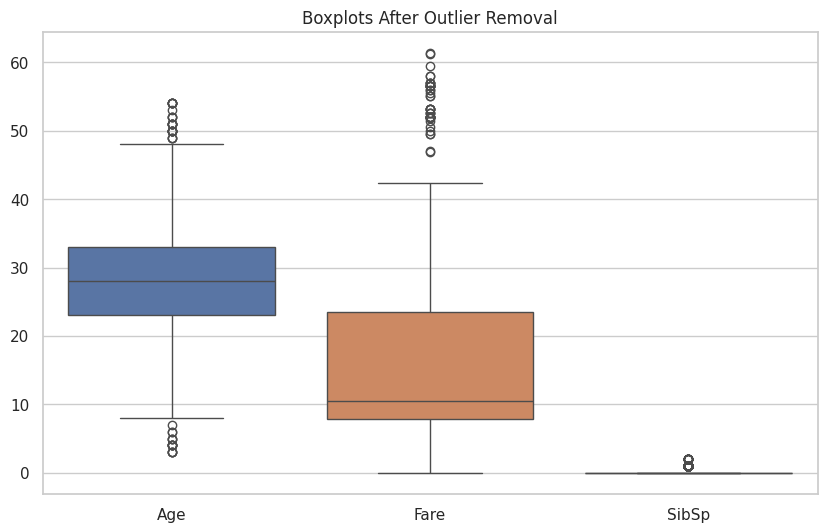

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_no_outliers[num_cols_for_outliers])
plt.title("Boxplots After Outlier Removal")
plt.show()

In [ ]:
# Re-define target and features after outlier removal
y_clean = df_no_outliers["Survived"]
X_clean = df_no_outliers.drop(columns=drop_cols)

# Fit preprocessing pipeline and transform
X_processed = preprocessing_pipeline.fit_transform(X_clean)

print("Processed feature shape:", X_processed.shape)

Processed feature shape: (689, 10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (551, 10)
Test shape: (138, 10)


In [ ]:
!git init
!git config user.email "roy.purab.28@gmail.com"
!git config user.name "Purab Roy"

Reinitialized existing Git repository in /content/.git/


In [ ]:
# List files to confirm names
!ls

drive  sample_data


In [ ]:
!git add task1_titanic_preprocessing.ipynb
!git add train.csv   # optional; you can skip if you don't want dataset in repo

fatal: pathspec 'task1_titanic_preprocessing.ipynb' did not match any files
fatal: pathspec 'train.csv' did not match any files


In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
os.listdir("/content")

['.config', 'drive', '.git', 'sample_data']